# Head-direction cells in mouse postsubiculum (DANDI:000939)

A head-direction (HD) cell fires whenever the animal's head points in a
particular direction in the horizontal plane, regardless of where the animal is
or what it is doing. This notebook demonstrates the phenomenon end-to-end on
real extracellular recordings streamed from the DANDI Archive, and then pushes
past the basic tuning curve to ask what the population does collectively.

**Dataset.** [DANDI:000939](https://dandiarchive.org/dandiset/000939),
"Large-scale recordings of head direction cells in mouse postsubiculum"
(Duszkiewicz, Peyrache and colleagues). Silicon-probe recordings from mouse
postsubiculum during open-field foraging, with tracked head direction and
scored sleep states. The files are 20-30 GB each because they contain the raw
broadband traces; we stream them with `remfile` and only ever touch the spike
times, the behaviour, and the interval tables, so nothing like that volume is
actually transferred.

**What is shown.**

1. Every data stream is plotted before it is analysed.
2. Directional tuning curves, with significance assessed against a
   time-shift null distribution and an effect-size criterion.
3. Stability: interleaved split halves within a session, and the same cells
   recorded in two differently shaped arenas.
4. Population structure: the tuning curves tile the compass, co-firing falls
   off with the difference in preferred direction, and the population activity
   forms a single bump that tracks the head.
5. Bayesian decoding of head direction from spikes alone, trained in one arena
   and tested in another, plus what the same decoder reports during sleep.
6. The whole pipeline repeated across six sessions from six mice.

In [1]:
import pickle

import matplotlib

matplotlib.use("Agg")  # this notebook is written to run headless
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from tqdm.auto import tqdm

from IPython.display import Image, display  # embeds figures, no GUI needed

import hd_lib  # loading and circular-statistics helpers used throughout

plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "figure.dpi": 150})

NB_BINS = 120        # angular bins for tuning curves (3 degrees each)
N_SHUFFLES = 200     # time-shift shuffles for the null distribution
MVL_THRESHOLD = 0.3  # effect-size floor for calling a unit an HD cell
BIN = 0.2            # decoding bin (s)
SESSION = "c72bd94f-b744-483e-a782-3a3c475a5276"  # sub-A3705, ses-200306


def save_and_show(fig, path):
    """Write the figure to disk and embed it in the notebook. No plt.show()."""
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=path))


def wrap_nan(y_deg):
    """Insert NaNs at 0/360 wraps so plotted traces do not draw vertical jumps."""
    y = np.asarray(y_deg, dtype=float).copy()
    y[1:][np.abs(np.diff(y)) > 180] = np.nan
    return y

## 1. Load one session and inspect every stream

`hd_lib.session_bundle` opens the NWB file over S3, hands it to Pynapple, and
returns the spike trains (`TsGroup`), head direction (`Tsd`, radians), position
(`TsdFrame`, cm), the behavioural epochs and the sleep-state intervals. Head
direction has occasional tracking dropouts, which are removed at load time.

In [2]:
s = hd_lib.session_bundle(SESSION)
units, hd, pos, wake = s["units"], s["hd"], s["position"], s["wake"]
labels = s["epoch_labels"]
square = nap.IntervalSet(s["epochs"].start[labels == "wake_square"],
                         s["epochs"].end[labels == "wake_square"])
triangle = nap.IntervalSet(s["epochs"].start[labels == "wake_triangle"],
                           s["epochs"].end[labels == "wake_triangle"])

print("session:", s["name"], " subject:", s["subject"])
print("epochs:", list(zip(labels, np.round(s["epochs"].start), np.round(s["epochs"].end))))
print("wake total: %.1f min" % (wake.tot_length() / 60))
print("head-direction samples: %d (%d NaN dropped), sampling %.3f s"
      % (len(hd), s["n_hd_nan"], np.median(np.diff(hd.t))))
print("units: %d, all in %s" % (len(units), set(np.asarray(units.location))))
print("wake firing rate: median %.2f Hz (range %.2f-%.2f)"
      % (np.median(units.restrict(wake).rates), units.restrict(wake).rates.min(),
         units.restrict(wake).rates.max()))

/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
  data = nap.IntervalSet(df)


session: A3705  subject: A3705
epochs: [(np.str_('home_cage'), np.float64(0.0), np.float64(5030.0)), (np.str_('wake_square'), np.float64(5030.0), np.float64(7669.0)), (np.str_('home_cage'), np.float64(7669.0), np.float64(13711.0)), (np.str_('wake_triangle'), np.float64(13711.0), np.float64(16199.0))]
wake total: 85.4 min
head-direction samples: 508639 (2804 NaN dropped), sampling 0.010 s
units: 117, all in {np.str_('Postsubiculum')}
wake firing rate: median 4.01 Hz (range 0.43-74.62)


The session alternates home-cage rest (which contains the scored sleep) with
two foraging sessions in differently shaped arenas. The bottom panel is the
phenomenon in raw form: 25 tuned cells ordered by preferred direction, coloured
on a circular colour map, with the tracked head direction drawn on top. Spiking
marches up and down the ordering as the animal turns.

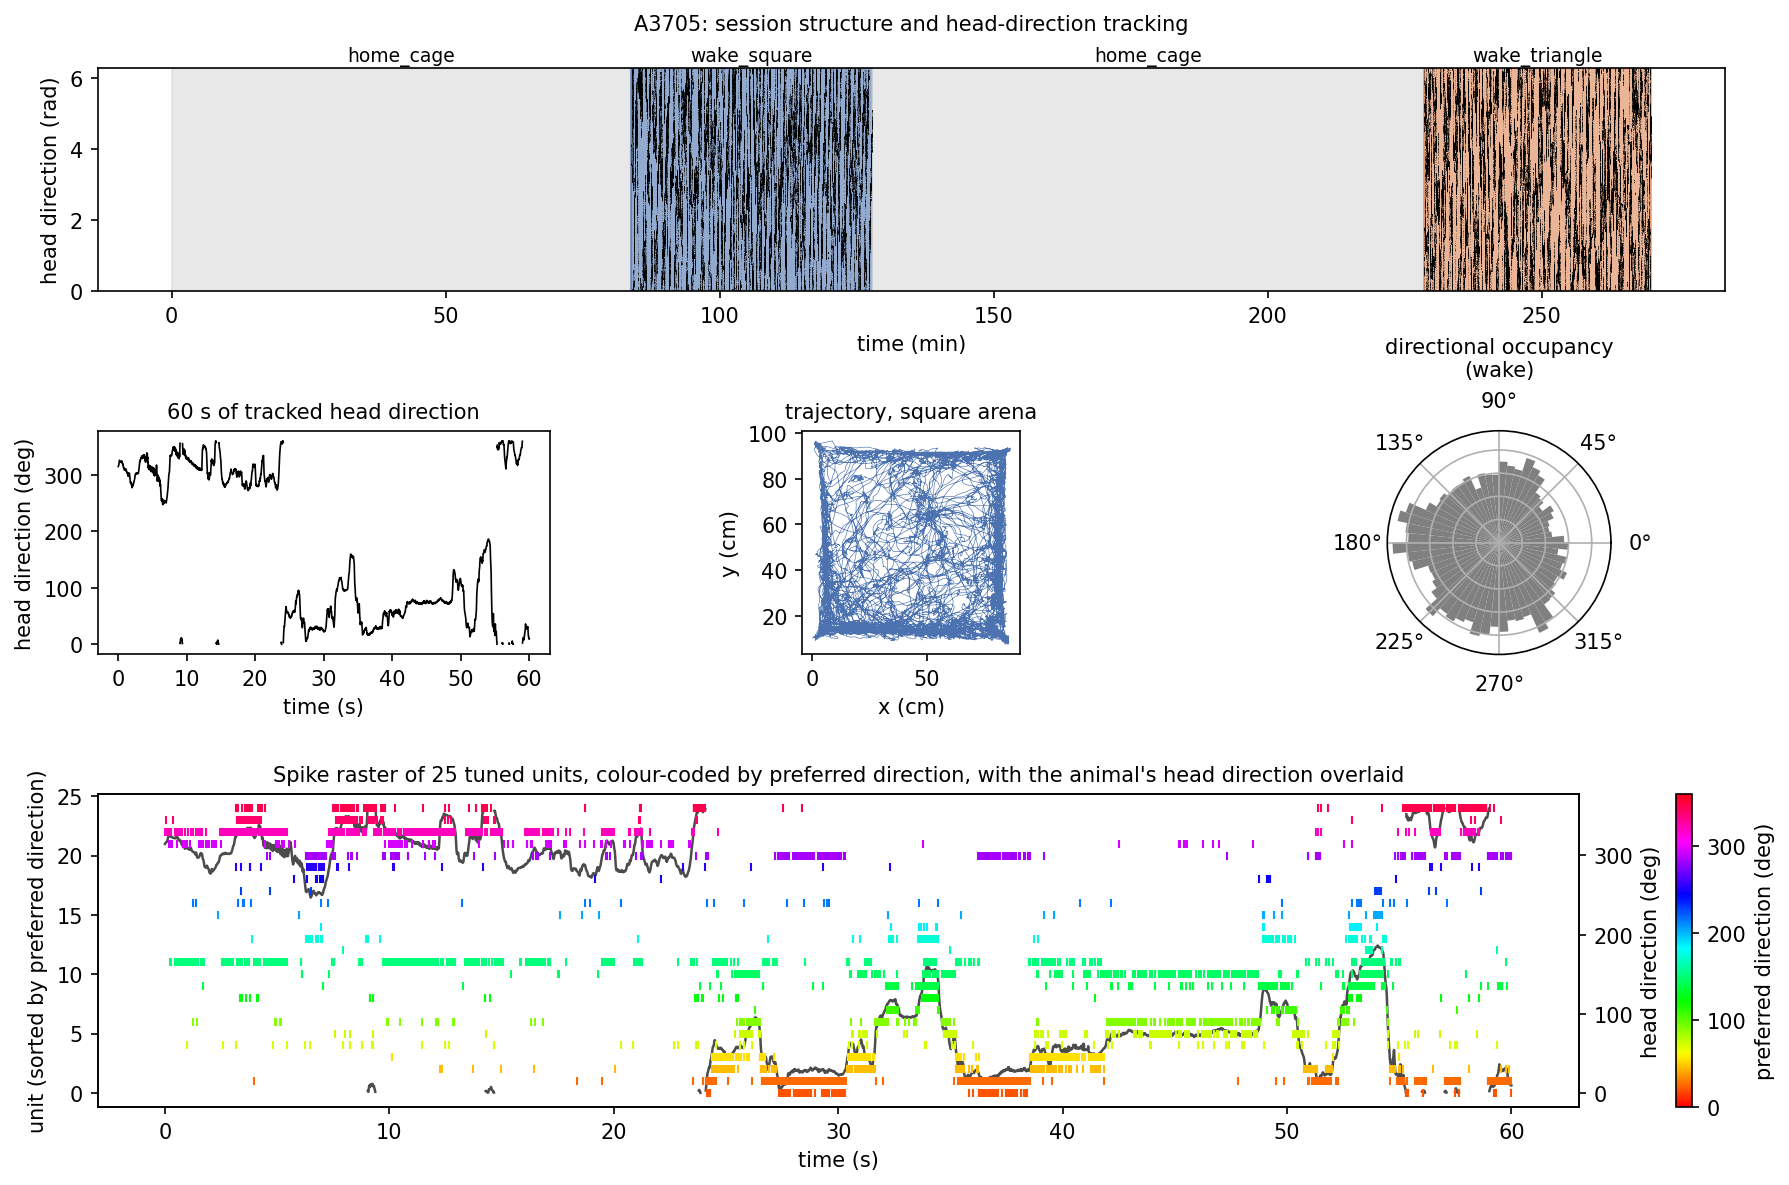

In [3]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.4], hspace=0.55, wspace=0.3)

ax = fig.add_subplot(gs[0, :])
colors = {"home_cage": "0.85", "wake_square": "#4C72B0", "wake_triangle": "#DD8452"}
for lbl, st, en in zip(labels, s["epochs"].start, s["epochs"].end):
    ax.axvspan(st / 60, en / 60, color=colors.get(lbl, "0.6"), alpha=0.6)
    ax.text((st + en) / 2 / 60, 1.03, lbl, ha="center", fontsize=9,
            transform=ax.get_xaxis_transform())
ax.plot(hd.t / 60, hd.d, ",", color="k", alpha=0.3)
ax.set_xlabel("time (min)")
ax.set_ylabel("head direction (rad)")
ax.set_title(f"{s['name']}: session structure and head-direction tracking", pad=18)
ax.set_ylim(0, 2 * np.pi)

t0 = wake.start[0] + 100
seg = nap.IntervalSet(t0, t0 + 60)
ax = fig.add_subplot(gs[1, 0])
h = hd.restrict(seg)
ax.plot(h.t - t0, wrap_nan(np.degrees(h.d)), "k-", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("head direction (deg)")
ax.set_title("60 s of tracked head direction")

ax = fig.add_subplot(gs[1, 1])
p = pos.restrict(square)
ax.plot(p["x"].values, p["y"].values, lw=0.3, color="#4C72B0")
ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_title("trajectory, square arena")

ax = fig.add_subplot(gs[1, 2], projection="polar")
occ = hd_lib.angular_occupancy(hd, wake, 60)
edges = np.linspace(0, 2 * np.pi, 61)
ax.bar(edges[:-1], occ, width=np.diff(edges), align="edge", color="0.5")
ax.set_title("directional occupancy\n(wake)", pad=26)
ax.set_yticklabels([])

ax = fig.add_subplot(gs[2, :])
tc_probe, stats_probe = hd_lib.tuning_stats(units, hd, wake, NB_BINS)
hd_lab = np.asarray(units.is_head_direction).astype(bool)
order_probe = stats_probe.sort_values("pref_dir").index
tuned = [u for u in order_probe if hd_lab[list(units.keys()).index(u)]]
sel = [tuned[i] for i in np.linspace(0, len(tuned) - 1, 25).astype(int)]
for i, u in enumerate(sel):
    st = units[u].restrict(seg).t
    ax.plot(st - t0, np.full_like(st, i), "|", ms=4,
            color=plt.cm.hsv(stats_probe.loc[u, "pref_dir"] / (2 * np.pi)))
sm = plt.cm.ScalarMappable(cmap="hsv", norm=plt.Normalize(0, 360))
fig.colorbar(sm, ax=ax, pad=0.06, fraction=0.03).set_label("preferred direction (deg)")
ax.set_ylabel("unit (sorted by preferred direction)")
ax.set_xlabel("time (s)")
ax.set_title("Spike raster of 25 tuned units, colour-coded by preferred direction, "
             "with the animal's head direction overlaid")
ax2 = ax.twinx()
ax.set_zorder(2)
ax.patch.set_visible(False)
ax2.set_zorder(1)
ax2.plot(h.t - t0, wrap_nan(np.degrees(h.d)), "k-", lw=1.2, alpha=0.7)
ax2.set_ylabel("head direction (deg)")
save_and_show(fig, "fig01_data_validation.png")

## 2. Tuning curves and how to tell a real one from an accident

A tuning curve is the firing rate as a function of head direction, occupancy
corrected. Pynapple's `compute_tuning_curves` does the binning. Two summary
statistics describe it: the **mean vector length** (MVL), which is the
resultant length of the rate-weighted direction vectors and runs from 0 for a
flat curve to 1 for a delta function, and the **directional information** in
bits per spike.

For a null distribution we circularly shift the head-direction signal in time
relative to the spikes by a random offset of at least 20 s. This preserves the
spike-train statistics and the statistics of the animal's behaviour, and
destroys only the pairing between them.

In [4]:
tc, stats = hd_lib.tuning_stats(units, hd, wake, NB_BINS)
stats["is_hd_dataset"] = np.asarray(units.is_head_direction).astype(bool)
stats["is_fs"] = np.asarray(units.is_fast_spiking).astype(bool)

mvl_null, info_null, unit_order = hd_lib.shuffle_null(
    units, hd, wake, n_shuffles=N_SHUFFLES, nb_bins=NB_BINS, seed=1,
    tqdm_desc="shuffles")
assert list(stats.index) == list(unit_order)

stats["mvl_p99"] = np.percentile(mvl_null, 99, axis=0)
stats["info_p99"] = np.percentile(info_null, 99, axis=0)
stats["mvl_z"] = (stats["mvl"] - mvl_null.mean(0)) / mvl_null.std(0)
stats["is_significant"] = (stats["mvl"] > stats["mvl_p99"]) & \
                          (stats["hd_info"] > stats["info_p99"])
stats["is_hd"] = stats["is_significant"] & (stats["mvl"] >= MVL_THRESHOLD)
hd_cells = list(stats.index[stats["is_hd"]])

print("significantly direction-modulated: %d / %d"
      % (stats["is_significant"].sum(), len(stats)))
print("HD cells (also MVL >= %.1f): %d / %d" % (MVL_THRESHOLD, len(hd_cells), len(stats)))
print(pd.crosstab(stats["is_hd"], stats["is_hd_dataset"]))

shuffles:   0%|                               | 0/200 [00:00<?, ?it/s]

significantly direction-modulated: 107 / 117
HD cells (also MVL >= 0.3): 62 / 117
is_hd_dataset  False  True 
is_hd                      
False             45     10
True               6     56


Note the gap between those two numbers. With more than an hour of wake data,
91% of the units are *statistically* modulated by head direction at p < 0.01,
because even a few percent of rate modulation is detectable given enough
spikes. Statistical significance is therefore not a useful classifier here; an
effect-size floor is what separates cells that carry a directional signal from
cells that are merely touched by one. With MVL >= 0.3 the classification
matches the dataset's own published `is_head_direction` flag on 86% of units.

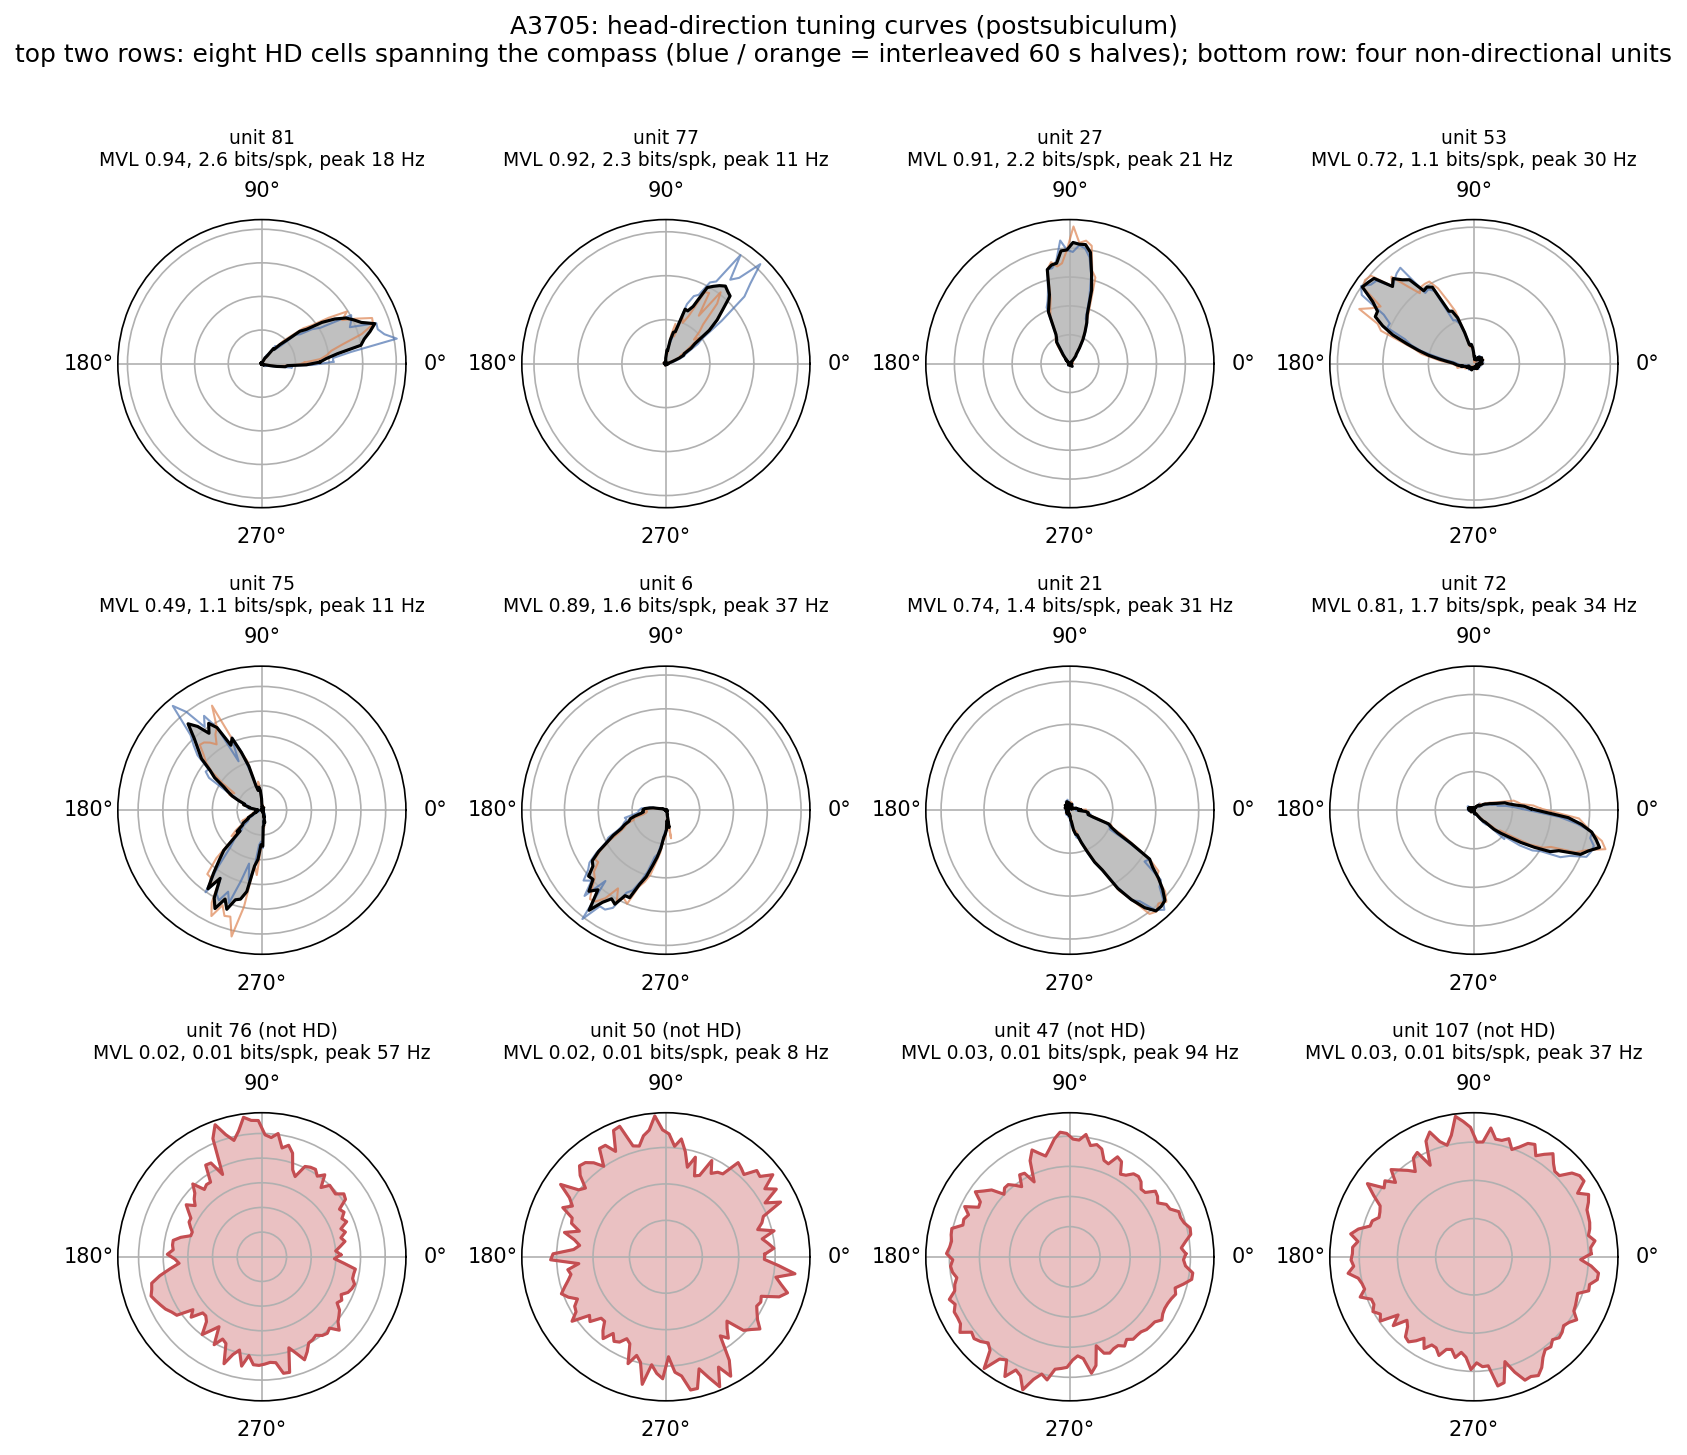

In [5]:
sel = stats.loc[hd_cells].sort_values("pref_dir").index.values
examples = sel[np.linspace(0, len(sel) - 1, 8).astype(int)]
non_hd = stats[~stats["is_hd"]].sort_values("mvl").index.values[:4]

# Interleaved 60 s blocks, used here to overlay two independent estimates.
def alternating_halves(ep, block=60.0):
    starts, ends = [], []
    for st, en in zip(ep.start, ep.end):
        edges = np.arange(st, en, block)
        starts.extend(edges)
        ends.extend(np.minimum(edges + block, en))
    starts, ends = np.array(starts), np.array(ends)
    return nap.IntervalSet(starts[::2], ends[::2]), nap.IntervalSet(starts[1::2], ends[1::2])


ep_a, ep_b = alternating_halves(wake)
tc_a = hd_lib.compute_tuning(units, hd, ep_a, NB_BINS)
tc_b = hd_lib.compute_tuning(units, hd, ep_b, NB_BINS)

fig, axes = plt.subplots(3, 4, figsize=(13, 10.5), subplot_kw={"projection": "polar"})
ang_c = np.append(np.asarray(tc.index), np.asarray(tc.index)[0])
for ax, u in zip(axes.ravel()[:8], examples):
    r = np.append(tc[u].values, tc[u].values[0])
    ax.plot(ang_c, np.append(tc_a[u].values, tc_a[u].values[0]), color="#4C72B0",
            lw=1, alpha=0.7)
    ax.plot(ang_c, np.append(tc_b[u].values, tc_b[u].values[0]), color="#DD8452",
            lw=1, alpha=0.7)
    ax.fill(ang_c, r, color="0.3", alpha=0.35)
    ax.plot(ang_c, r, color="k", lw=1.5)
    ax.set_title("unit %d\nMVL %.2f, %.1f bits/spk, peak %.0f Hz"
                 % (u, stats.loc[u, "mvl"], stats.loc[u, "hd_info"],
                    stats.loc[u, "peak_rate"]), pad=26, fontsize=9)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_yticklabels([])
for ax, u in zip(axes.ravel()[8:], non_hd):
    r = np.append(tc[u].values, tc[u].values[0])
    ax.fill(ang_c, r, color="#C44E52", alpha=0.35)
    ax.plot(ang_c, r, color="#C44E52", lw=1.5)
    ax.set_title("unit %d (not HD)\nMVL %.2f, %.2f bits/spk, peak %.0f Hz"
                 % (u, stats.loc[u, "mvl"], stats.loc[u, "hd_info"],
                    stats.loc[u, "peak_rate"]), pad=26, fontsize=9)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_yticklabels([])
fig.suptitle(f"{s['name']}: head-direction tuning curves (postsubiculum)\n"
             "top two rows: eight HD cells spanning the compass "
             "(blue / orange = interleaved 60 s halves); bottom row: four "
             "non-directional units", y=0.99)
fig.subplots_adjust(hspace=0.55, wspace=0.35, top=0.86)
save_and_show(fig, "fig02_tuning_curves.png")

The tuned cells have narrow unimodal curves with peak rates of 10-40 Hz and
near-silence elsewhere, and the two interleaved halves lie on top of each
other. The non-directional units in the bottom row are fast-firing and flat.

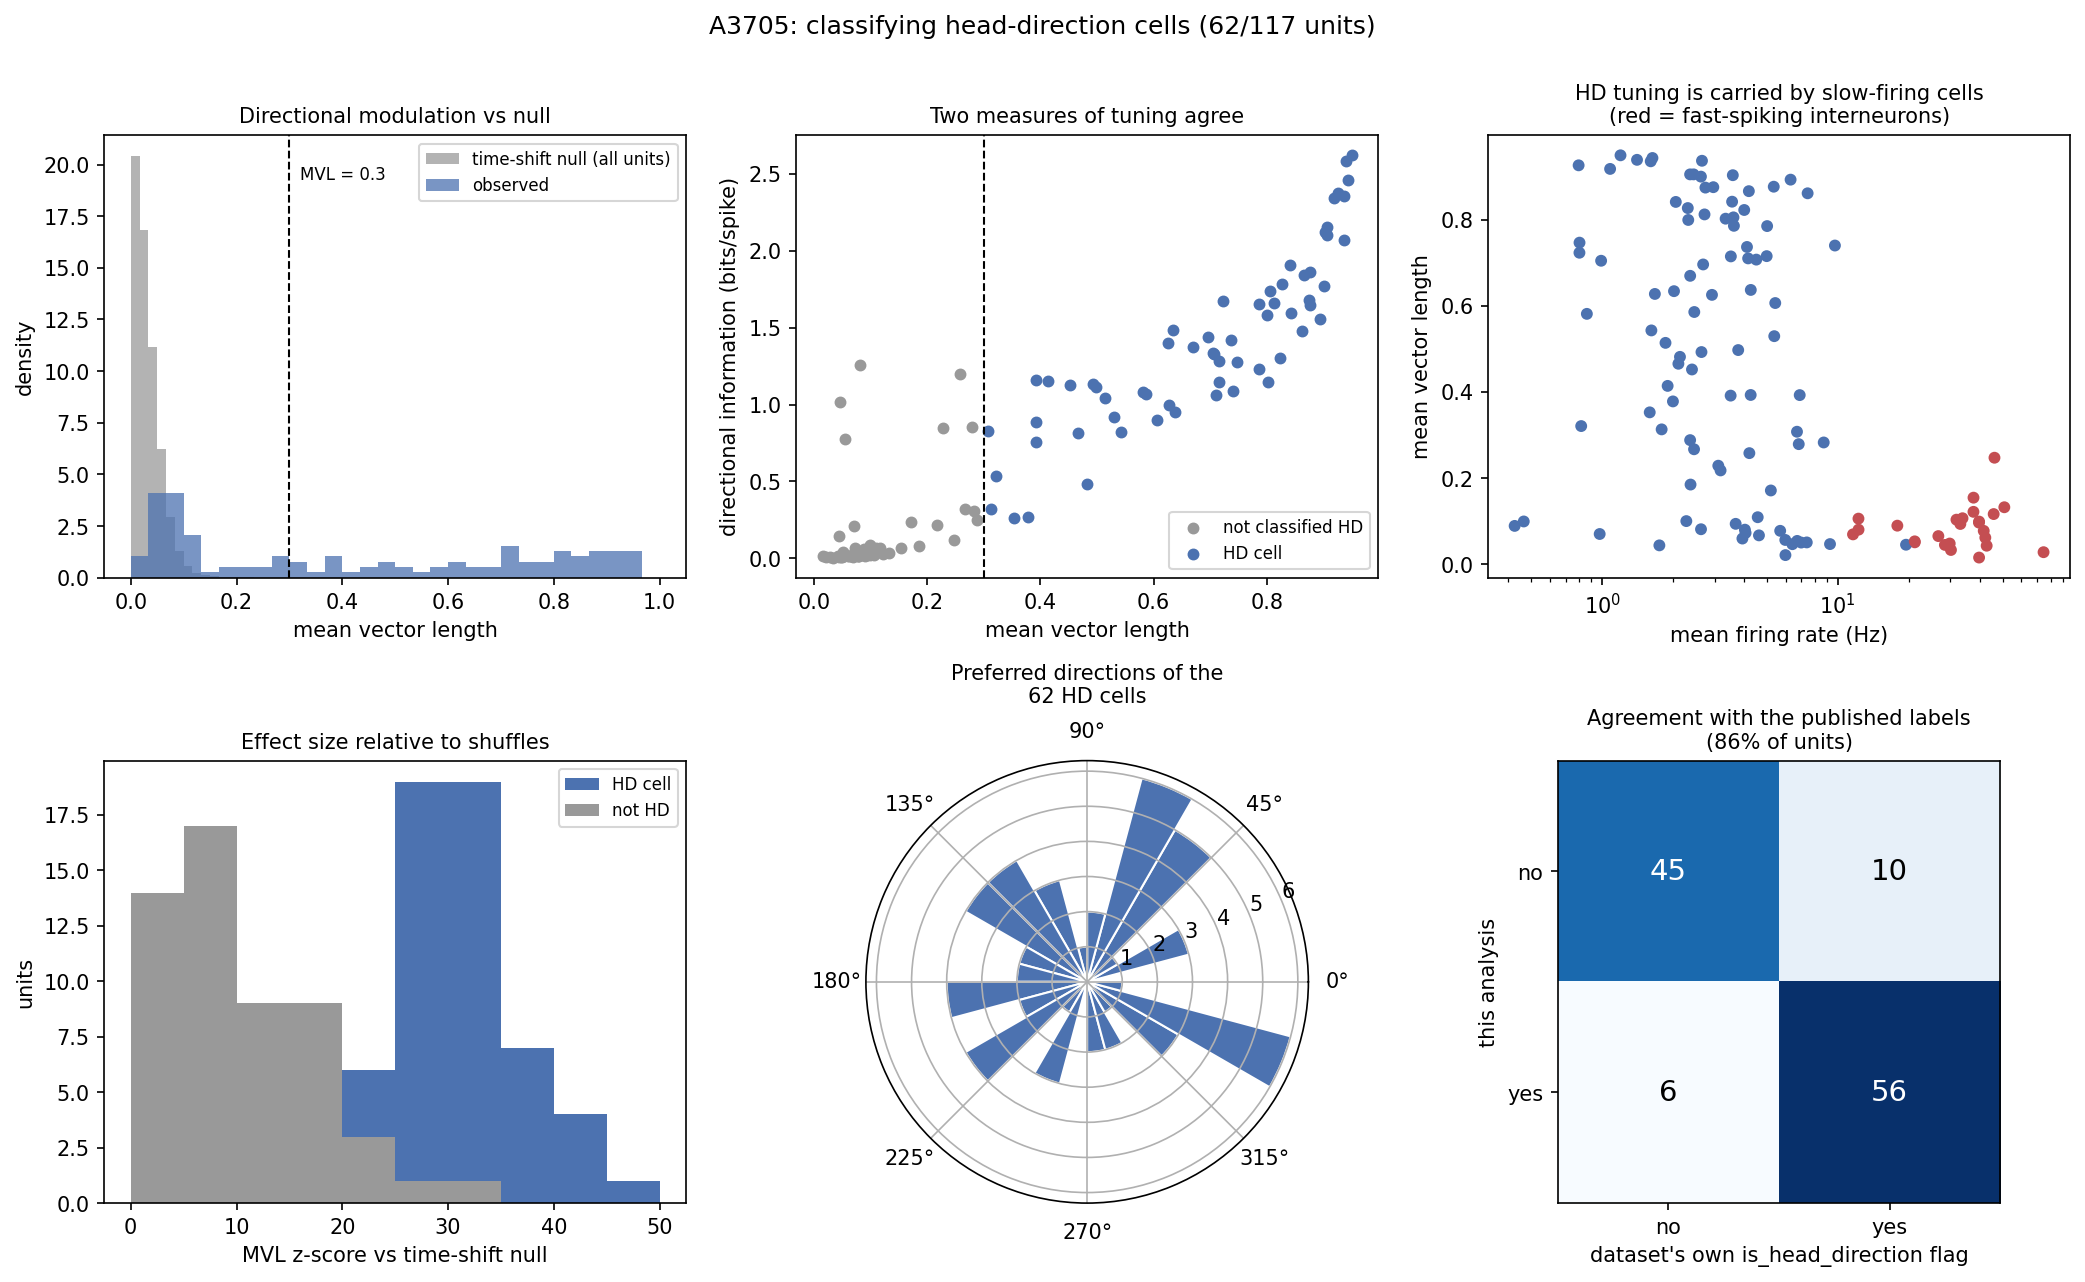

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))

ax = axes[0, 0]
ax.hist(mvl_null.ravel(), bins=60, range=(0, 1), color="0.7", density=True,
        label="time-shift null (all units)")
ax.hist(stats["mvl"], bins=30, range=(0, 1), color="#4C72B0", alpha=0.75,
        density=True, label="observed")
ax.axvline(MVL_THRESHOLD, color="k", ls="--", lw=1)
ax.text(MVL_THRESHOLD + 0.02, ax.get_ylim()[1] * 0.9, "MVL = 0.3", fontsize=8)
ax.set_xlabel("mean vector length")
ax.set_ylabel("density")
ax.set_title("Directional modulation vs null")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(stats.loc[~stats["is_hd"], "mvl"], stats.loc[~stats["is_hd"], "hd_info"],
           s=22, color="0.6", label="not classified HD")
ax.scatter(stats.loc[stats["is_hd"], "mvl"], stats.loc[stats["is_hd"], "hd_info"],
           s=22, color="#4C72B0", label="HD cell")
ax.axvline(MVL_THRESHOLD, color="k", ls="--", lw=1)
ax.set_xlabel("mean vector length")
ax.set_ylabel("directional information (bits/spike)")
ax.set_title("Two measures of tuning agree")
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.scatter(stats["mean_rate"], stats["mvl"],
           c=np.where(stats["is_fs"], "#C44E52", "#4C72B0"), s=22)
ax.set_xscale("log")
ax.set_xlabel("mean firing rate (Hz)")
ax.set_ylabel("mean vector length")
ax.set_title("HD tuning is carried by slow-firing cells\n"
             "(red = fast-spiking interneurons)")

ax = axes[1, 0]
z = stats["mvl_z"].values
bins_z = np.arange(0, max(z) + 5, 5)
ax.hist(z[stats["is_hd"]], bins=bins_z, color="#4C72B0", label="HD cell")
ax.hist(z[~stats["is_hd"]], bins=bins_z, color="0.6", label="not HD")
ax.set_xlabel("MVL z-score vs time-shift null")
ax.set_ylabel("units")
ax.set_title("Effect size relative to shuffles")
ax.legend(fontsize=8)

axes[1, 1].remove()
ax = fig.add_subplot(2, 3, 5, projection="polar")
edges = np.linspace(0, 2 * np.pi, 25)
cnt, _ = np.histogram(stats.loc[hd_cells, "pref_dir"], edges)
ax.bar(edges[:-1], cnt, width=np.diff(edges), align="edge", color="#4C72B0",
       edgecolor="w")
ax.set_title("Preferred directions of the\n%d HD cells" % len(hd_cells), pad=28)

ax = axes[1, 2]
ct = np.array([[np.sum(~stats["is_hd"] & ~stats["is_hd_dataset"]),
                np.sum(~stats["is_hd"] & stats["is_hd_dataset"])],
               [np.sum(stats["is_hd"] & ~stats["is_hd_dataset"]),
                np.sum(stats["is_hd"] & stats["is_hd_dataset"])]])
ax.imshow(ct, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, ct[i, j], ha="center", va="center", fontsize=14,
                color="w" if ct[i, j] > ct.max() / 2 else "k")
ax.set_xticks([0, 1], ["no", "yes"])
ax.set_yticks([0, 1], ["no", "yes"])
ax.set_xlabel("dataset's own is_head_direction flag")
ax.set_ylabel("this analysis")
ax.set_title("Agreement with the published labels\n(%.0f%% of units)"
             % (100 * (ct[0, 0] + ct[1, 1]) / ct.sum()))
fig.suptitle(f"{s['name']}: classifying head-direction cells "
             f"({len(hd_cells)}/{len(stats)} units)", y=1.0)
fig.tight_layout()
save_and_show(fig, "fig03_population_statistics.png")

## 3. Stability within a session and across environments

Directional tuning that only holds for a few minutes, or that is really a
disguised place field, would not deserve the name. Two checks: the tuning curve
computed from interleaved 60 s blocks (which controls for slow drift), and the
tuning curve computed separately in the square and the triangular arena.

In [7]:
tc_sq = hd_lib.compute_tuning(units, hd, square, NB_BINS)
tc_tr = hd_lib.compute_tuning(units, hd, triangle, NB_BINS)


def curve_corr(t1, t2):
    return np.array([np.corrcoef(t1[u].values, t2[u].values)[0, 1] for u in t1.columns])


stats["split_half_r"] = curve_corr(tc_a, tc_b)
stats["cross_env_r"] = curve_corr(tc_sq, tc_tr)
stats["pref_sq"] = [hd_lib.mean_vector(tc_sq[u])[1] for u in tc_sq.columns]
stats["pref_tr"] = [hd_lib.mean_vector(tc_tr[u])[1] for u in tc_tr.columns]
stats["pref_shift"] = hd_lib.circ_diff(stats["pref_tr"], stats["pref_sq"])

print("HD cells, split-half r: median %.2f" % stats.loc[hd_cells, "split_half_r"].median())
print("HD cells, square vs triangle r: median %.2f"
      % stats.loc[hd_cells, "cross_env_r"].median())
print("preferred-direction shift across arenas: median %.0f deg, IQR %.0f deg"
      % (np.degrees(np.median(stats.loc[hd_cells, "pref_shift"])),
         np.degrees(np.subtract(*np.percentile(stats.loc[hd_cells, "pref_shift"],
                                               [75, 25])))))

HD cells, split-half r: median 0.97
HD cells, square vs triangle r: median 0.85
preferred-direction shift across arenas: median 10 deg, IQR 8 deg


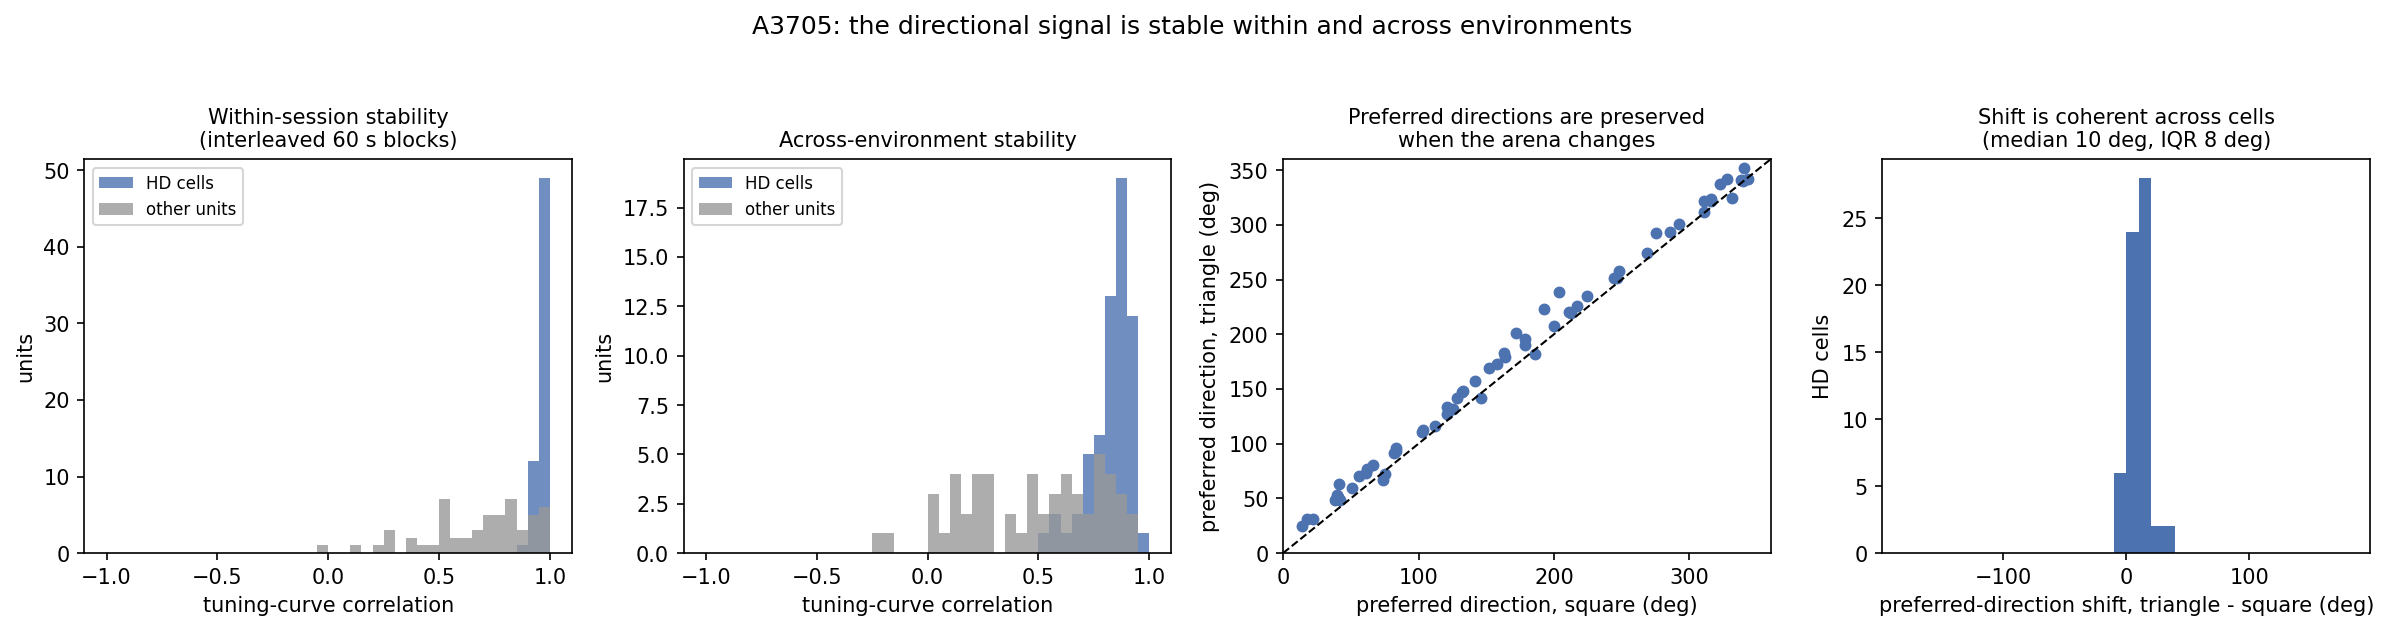

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
bins = np.linspace(-1, 1, 41)
for ax, col, title in [(axes[0], "split_half_r",
                        "Within-session stability\n(interleaved 60 s blocks)"),
                       (axes[1], "cross_env_r", "Across-environment stability")]:
    ax.hist(stats.loc[hd_cells, col], bins=bins, color="#4C72B0", alpha=0.8,
            label="HD cells")
    ax.hist(stats.loc[~stats["is_hd"], col], bins=bins, color="0.6", alpha=0.8,
            label="other units")
    ax.set_xlabel("tuning-curve correlation")
    ax.set_ylabel("units")
    ax.set_title(title)
    ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(np.degrees(stats.loc[hd_cells, "pref_sq"]),
           np.degrees(stats.loc[hd_cells, "pref_tr"]), s=22, color="#4C72B0")
ax.plot([0, 360], [0, 360], "k--", lw=1)
ax.set_xlabel("preferred direction, square (deg)")
ax.set_ylabel("preferred direction, triangle (deg)")
ax.set_title("Preferred directions are preserved\nwhen the arena changes")
ax.set_xlim(0, 360)
ax.set_ylim(0, 360)

ax = axes[3]
shift = np.degrees(stats.loc[hd_cells, "pref_shift"])
ax.hist(shift, bins=np.arange(-180, 190, 10), color="#4C72B0")
ax.set_xlabel("preferred-direction shift, triangle - square (deg)")
ax.set_ylabel("HD cells")
ax.set_title("Shift is coherent across cells\n(median %.0f deg, IQR %.0f deg)"
             % (np.median(shift), np.subtract(*np.percentile(shift, [75, 25]))))
fig.suptitle(f"{s['name']}: the directional signal is stable within and across "
             "environments", y=1.04)
fig.tight_layout()
save_and_show(fig, "fig04_stability.png")

The cells keep their preferred directions when the arena is swapped: the
scatter sits on the identity line, and the small residual offset is shared by
the whole population rather than being idiosyncratic per cell. The ensemble
rotates as a rigid ring; it does not remap.

In this session the rotation happens to be small (about 10 degrees), which is
why pooling the two arenas into a single `wake` epoch above was harmless. That
is not guaranteed. In one of the six sessions analysed in part 6 the ring
rotated by 166 degrees between the two arenas, and pooling them destroyed the
tuning curves of almost every cell. The multi-session pipeline therefore
computes tuning within one arena at a time.

## 4. Population structure

Sorting the HD cells by preferred direction shows the tuning curves tiling the
full circle. Because neighbouring cells on that ring are active at the same
time, spike-count correlations should fall off with the difference in preferred
direction, and the instantaneous population activity should be a single bump.

In [9]:
hd_units = units[hd_cells]
pref = stats.loc[hd_cells, "pref_dir"].values
counts = hd_units.count(0.25, wake)
cc = np.corrcoef(counts.values.T)
iu = np.triu_indices(len(hd_cells), 1)
pair_dphi = np.abs(hd_lib.circ_diff(pref[iu[0]], pref[iu[1]]))
pair_r = cc[iu]

sleep_states = s["sleep_states"]
state = np.asarray([np.asarray(x).ravel()[0] for x in sleep_states.state])
nrem = nap.IntervalSet(sleep_states.start[state == "nrem"],
                       sleep_states.end[state == "nrem"])
rem = nap.IntervalSet(sleep_states.start[state == "rem"],
                      sleep_states.end[state == "rem"])
pair_r_nrem = np.corrcoef(hd_units.count(0.25, nrem).values.T)[iu]

print("wake: r(|dpref|, co-firing) = %.2f" % np.corrcoef(pair_dphi, pair_r)[0, 1])
print("NREM: r(|dpref|, co-firing) = %.2f" % np.corrcoef(pair_dphi, pair_r_nrem)[0, 1])

wake: r(|dpref|, co-firing) = -0.63
NREM: r(|dpref|, co-firing) = -0.61


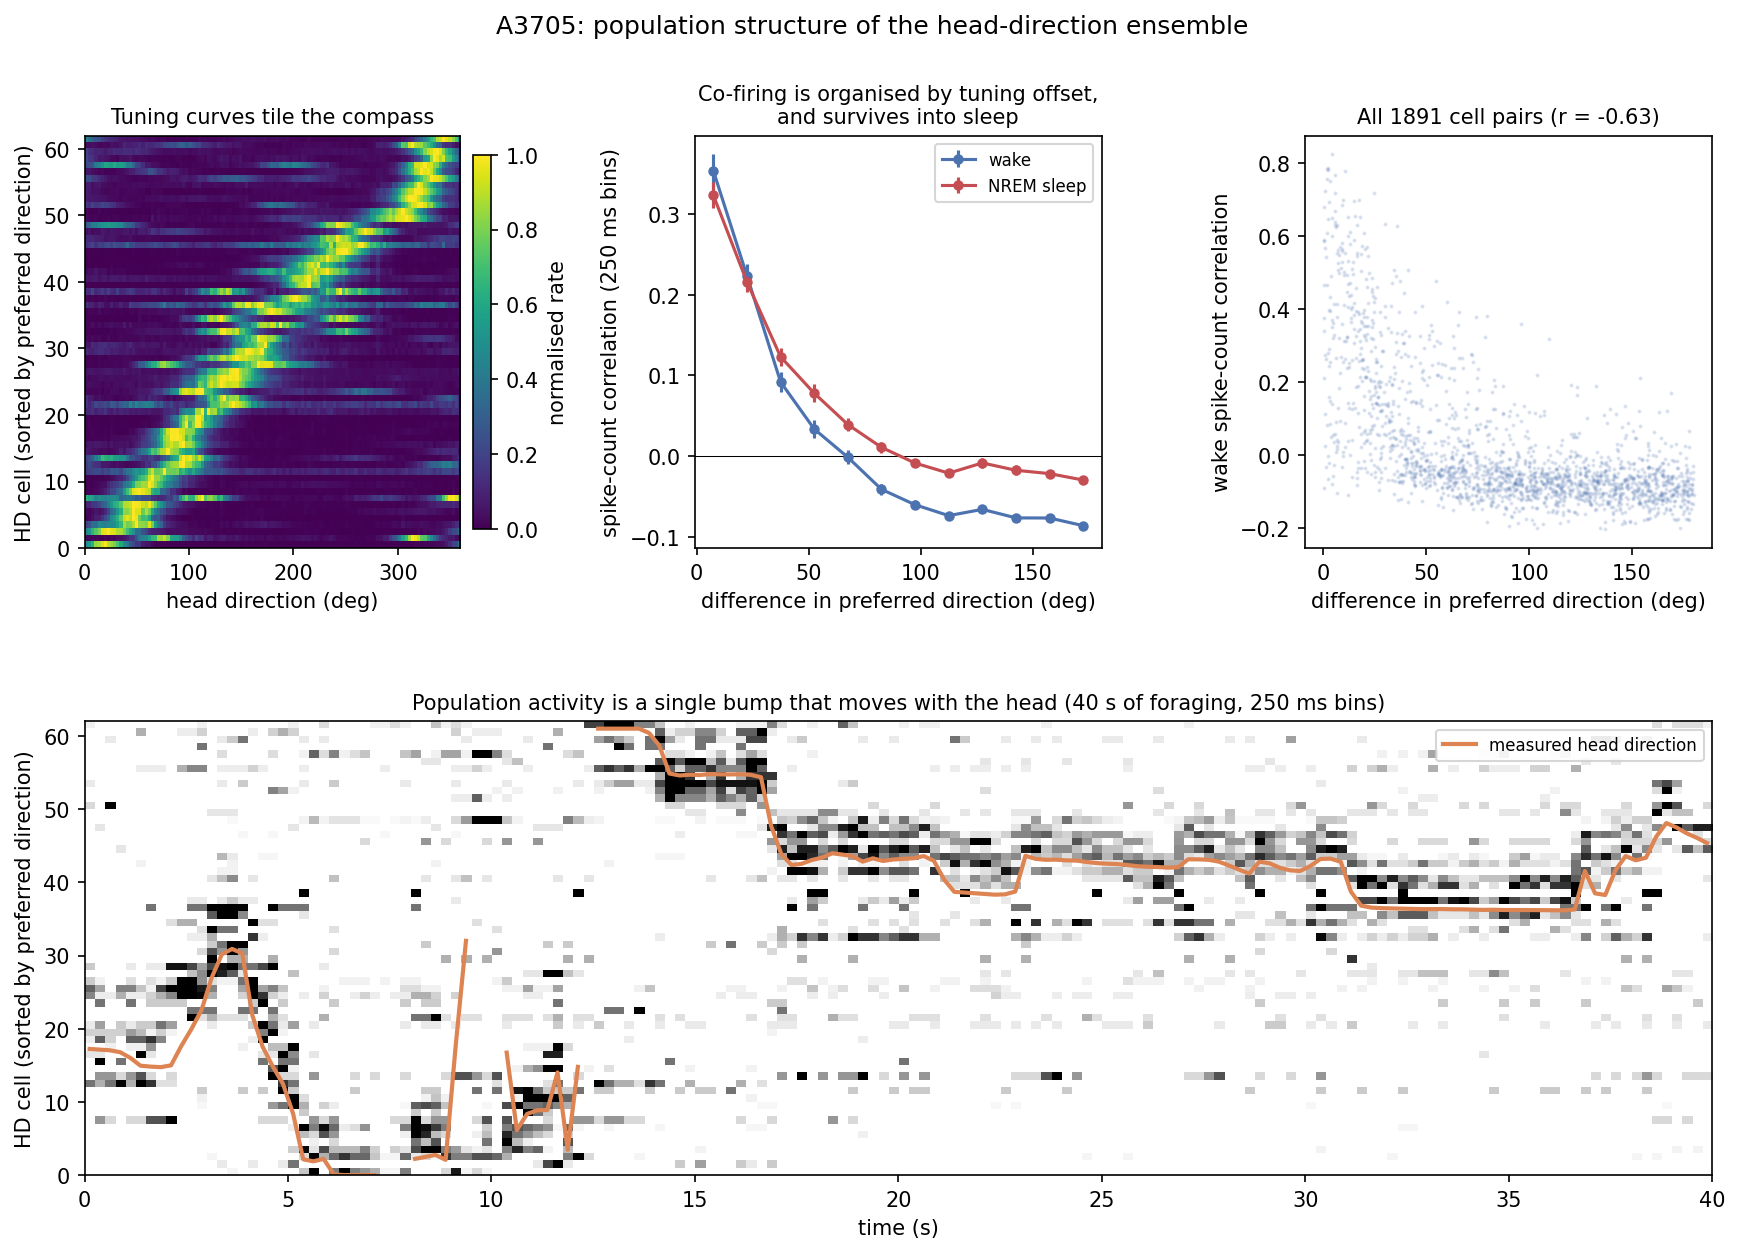

In [10]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1], hspace=0.4, wspace=0.5)

order = stats.loc[hd_cells].sort_values("pref_dir").index.values
M = np.stack([tc[u].values / tc[u].values.max() for u in order])
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(M, aspect="auto", origin="lower", cmap="viridis",
               extent=[0, 360, 0, len(order)])
ax.set_xlabel("head direction (deg)")
ax.set_ylabel("HD cell (sorted by preferred direction)")
ax.set_title("Tuning curves tile the compass")
fig.colorbar(im, ax=ax, label="normalised rate", fraction=0.046, pad=0.03)

ax = fig.add_subplot(gs[0, 1])
d = np.degrees(pair_dphi)
edges = np.arange(0, 190, 15)
idx = np.digitize(d, edges) - 1
for y, color, lab in [(pair_r, "#4C72B0", "wake"), (pair_r_nrem, "#C44E52", "NREM sleep")]:
    m = np.array([np.mean(y[idx == i]) for i in range(len(edges) - 1)])
    e = np.array([np.std(y[idx == i]) / np.sqrt(max(1, np.sum(idx == i)))
                  for i in range(len(edges) - 1)])
    ax.errorbar(edges[:-1] + 7.5, m, yerr=e, color=color, marker="o", ms=4, label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("difference in preferred direction (deg)")
ax.set_ylabel("spike-count correlation (250 ms bins)")
ax.set_title("Co-firing is organised by tuning offset,\nand survives into sleep")
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[0, 2])
ax.scatter(d, pair_r, s=1, alpha=0.15, color="#4C72B0")
ax.set_xlabel("difference in preferred direction (deg)")
ax.set_ylabel("wake spike-count correlation")
ax.set_title("All %d cell pairs (r = %.2f)" % (len(d), np.corrcoef(d, pair_r)[0, 1]))

ax = fig.add_subplot(gs[1, :])
t1 = triangle.start[0] + 300
seg = nap.IntervalSet(t1, t1 + 40)
c = counts.restrict(seg)
Mt = c.values[:, [list(counts.columns).index(u) for u in order]].T
Mt = Mt / (Mt.max(axis=1, keepdims=True) + 1e-9)
ax.imshow(Mt, aspect="auto", origin="lower", cmap="Greys",
          extent=[0, 40, 0, len(order)], vmax=0.8)
pref_deg = np.degrees(stats.loc[order, "pref_dir"].values)
truehd = hd.restrict(seg).bin_average(0.25, seg)
row = np.interp(np.degrees(truehd.values), pref_deg, np.arange(len(order)))
ax.plot(truehd.t - t1, wrap_nan(row / len(order) * 360) / 360 * len(order),
        color="#DD8452", lw=2, label="measured head direction")
ax.set_xlabel("time (s)")
ax.set_ylabel("HD cell (sorted by preferred direction)")
ax.set_title("Population activity is a single bump that moves with the head "
             "(40 s of foraging, 250 ms bins)")
ax.legend(loc="upper right", fontsize=8)
fig.suptitle(f"{s['name']}: population structure of the head-direction ensemble", y=0.97)
save_and_show(fig, "fig05_population_structure.png")

## 5. Decoding head direction from spikes

If the population really carries the animal's heading, a decoder trained in one
arena should recover it in another. We fit tuning curves in the square arena
and apply Pynapple's Bayesian decoder to 200 ms bins of spiking in the
triangular arena, which the decoder has never seen. The control keeps the same
spikes and the same set of tuning curves but permutes which curve belongs to
which cell.

In [11]:
tc_train = hd_lib.compute_tuning_xr(hd_units, hd, square, NB_BINS // 2)
decoded, proba = nap.decode_bayes(tc_train, hd_units, triangle, bin_size=BIN)
true_hd = hd.restrict(triangle).bin_average(BIN, triangle)
common = np.intersect1d(decoded.t, true_hd.t)
dec = decoded.values[np.isin(decoded.t, common)]
tru = true_hd.values[np.isin(true_hd.t, common)]
ok = ~np.isnan(tru)
err = np.degrees(hd_lib.circ_diff(dec[ok], tru[ok]))

rng = np.random.default_rng(0)
tc_perm = tc_train.copy()
tc_perm.values = tc_train.values[rng.permutation(tc_train.shape[0])]
dec_p, _ = nap.decode_bayes(tc_perm, hd_units, triangle, bin_size=BIN)
err_perm = np.degrees(hd_lib.circ_diff(
    dec_p.values[np.isin(dec_p.t, common)][ok], tru[ok]))

print("decoder: median |error| = %.1f deg, %.0f%% of bins within 30 deg (n = %d)"
      % (np.median(np.abs(err)), 100 * np.mean(np.abs(err) < 30), ok.sum()))
print("control: median |error| = %.1f deg" % np.median(np.abs(err_perm)))

decoder: median |error| = 13.6 deg, 85% of bins within 30 deg (n = 12374)
control: median |error| = 114.4 deg


The same decoder can be pointed at sleep, when the head is still. The measured
head direction is then meaningless, but the internal representation is not: it
keeps moving. We quantify that with the step size of the decoded direction
between consecutive 200 ms bins.

In [12]:
dec_rem, _ = nap.decode_bayes(tc_train, hd_units, rem, bin_size=BIN)
dec_nrem, _ = nap.decode_bayes(tc_train, hd_units, nrem, bin_size=BIN)


def drift_speed(dec_tsd, ep, bin_size=BIN):
    """Angular step of the decoded direction between consecutive bins (deg/s)."""
    steps = []
    for st, en in zip(ep.start, ep.end):
        segment = dec_tsd.restrict(nap.IntervalSet(st, en))
        if len(segment) < 3:
            continue
        steps.append(np.degrees(hd_lib.circ_diff(segment.values[1:],
                                                 segment.values[:-1])) / bin_size)
    return np.concatenate(steps) if steps else np.array([])


drift = {"wake (triangle)": drift_speed(decoded, triangle),
         "REM": drift_speed(dec_rem, rem),
         "NREM": drift_speed(dec_nrem, nrem)}
drift["shuffled"] = np.degrees(hd_lib.circ_diff(rng.permutation(decoded.values)[1:],
                                                rng.permutation(decoded.values)[:-1])) / BIN
for k, v in drift.items():
    print("%-16s median |step| = %5.1f deg/s, %.0f%% of steps < 18 deg"
          % (k, np.median(np.abs(v)), 100 * np.mean(np.abs(v) * BIN < 18)))

wake (triangle)  median |step| =  30.0 deg/s, 74% of steps < 18 deg
REM              median |step| =  30.0 deg/s, 81% of steps < 18 deg
NREM             median |step| = 270.0 deg/s, 30% of steps < 18 deg
shuffled         median |step| = 450.0 deg/s, 9% of steps < 18 deg


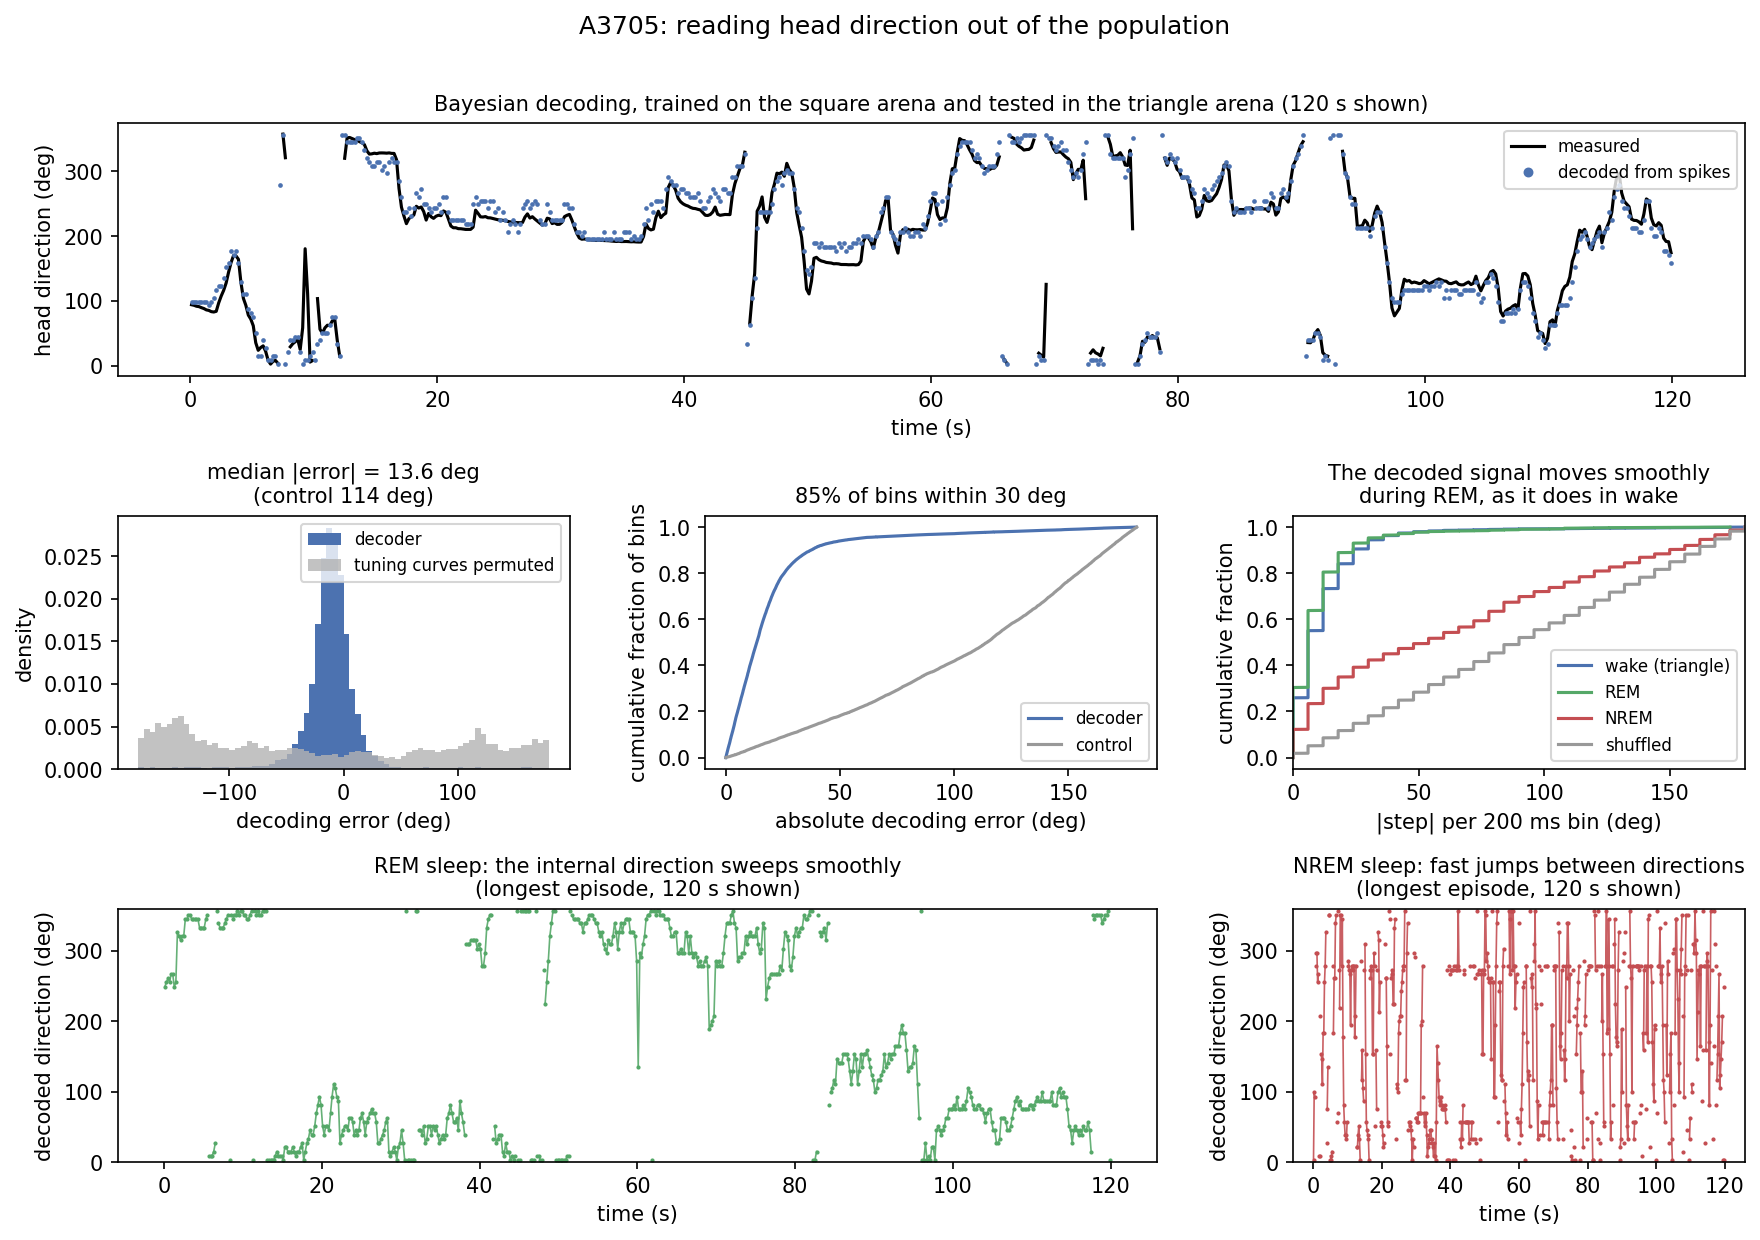

In [13]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.55, wspace=0.3)

ax = fig.add_subplot(gs[0, :])
seg = nap.IntervalSet(t1, t1 + 120)
d1, t1s = decoded.restrict(seg), true_hd.restrict(seg)
ax.plot(t1s.t - t1, wrap_nan(np.degrees(t1s.values)), "k-", lw=1.5, label="measured")
ax.plot(d1.t - t1, np.degrees(d1.values), ".", ms=2.5, color="#4C72B0",
        label="decoded from spikes")
ax.set_ylabel("head direction (deg)")
ax.set_xlabel("time (s)")
ax.set_title("Bayesian decoding, trained on the square arena and tested in the "
             "triangle arena (120 s shown)")
ax.legend(loc="upper right", fontsize=8, markerscale=3)

ax = fig.add_subplot(gs[1, 0])
bins_e = np.arange(-180, 185, 5)
ax.hist(err, bins=bins_e, color="#4C72B0", density=True, label="decoder")
ax.hist(err_perm, bins=bins_e, color="0.7", density=True, alpha=0.8,
        label="tuning curves permuted")
ax.set_xlabel("decoding error (deg)")
ax.set_ylabel("density")
ax.set_title("median |error| = %.1f deg\n(control %.0f deg)"
             % (np.median(np.abs(err)), np.median(np.abs(err_perm))))
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 1])
for v, color, lab in [(np.abs(err), "#4C72B0", "decoder"),
                      (np.abs(err_perm), "0.6", "control")]:
    x = np.sort(v)
    ax.plot(x, np.linspace(0, 1, len(x)), color=color, label=lab)
ax.set_xlabel("absolute decoding error (deg)")
ax.set_ylabel("cumulative fraction of bins")
ax.set_title("%.0f%% of bins within 30 deg" % (100 * np.mean(np.abs(err) < 30)))
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 2])
for k, color in [("wake (triangle)", "#4C72B0"), ("REM", "#55A868"),
                 ("NREM", "#C44E52"), ("shuffled", "0.6")]:
    x = np.sort(np.abs(drift[k]) * BIN)
    ax.plot(x, np.linspace(0, 1, len(x)), color=color, label=k)
ax.set_xlim(0, 180)
ax.set_xlabel("|step| per 200 ms bin (deg)")
ax.set_ylabel("cumulative fraction")
ax.set_title("The decoded signal moves smoothly\nduring REM, as it does in wake")
ax.legend(fontsize=8)

for col, (dtsd, ep, color, title) in enumerate([
        (dec_rem, rem, "#55A868", "REM sleep: the internal direction sweeps smoothly"),
        (dec_nrem, nrem, "#C44E52", "NREM sleep: fast jumps between directions")]):
    lengths = ep.end - ep.start
    i = int(np.argmax(lengths))
    dur = min(120, lengths[i])
    win = nap.IntervalSet(ep.start[i], ep.start[i] + dur)
    dd = dtsd.restrict(win)
    ax = fig.add_subplot(gs[2, 0:2] if col == 0 else gs[2, 2])
    ax.plot(dd.t - win.start[0], wrap_nan(np.degrees(dd.values)), "-", lw=0.8,
            color=color, alpha=0.9)
    ax.plot(dd.t - win.start[0], np.degrees(dd.values), ".", ms=2, color=color)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("decoded direction (deg)")
    ax.set_ylim(0, 360)
    ax.set_title("%s\n(longest episode, %.0f s shown)" % (title, dur))
fig.suptitle(f"{s['name']}: reading head direction out of the population", y=0.96)
save_and_show(fig, "fig06_decoding.png")

The decoder recovers head direction in a novel arena to a median of about 14
degrees, against 115 degrees for the permuted control (chance is 90 degrees).
During REM sleep the decoded direction moves as smoothly as it does in
waking, even though the animal is not moving: the ring attractor keeps running
on internal input alone. During NREM it jumps between directions much faster,
the signature of the rapid, replay-like activity of that state.

## 6. Across sessions and mice

`05_multi_session.py` runs the same pipeline (tuning curves, time-shift null,
MVL criterion, held-out decoding) on six sessions from six different mice and
writes `multi_session_summary.csv`, `multi_session_units.csv` and
`fig07_multi_session.png`. It takes some minutes because each session is
streamed from S3, so it is kept as a separate script; the cell below loads its
output if it is present.

Two differences from the single-session analysis above. Tuning is computed in
one arena at a time, for the reason given in part 3. And decoding is scored
three ways: trained and tested on interleaved blocks of the same arena, tested
in the other arena, and tested in the other arena after subtracting the single
session-wide rotation of the ensemble.

In [14]:
import os

if os.path.exists("multi_session_results.pkl"):
    with open("multi_session_results.pkl", "rb") as f:
        MS = pickle.load(f)
    print(MS["summary"].to_string(index=False))
    print("\npooled: %d units, %d HD cells (%.0f%%) across %d mice"
          % (len(MS["pooled"]), MS["pooled"]["is_hd"].sum(),
             100 * MS["pooled"]["is_hd"].mean(), MS["summary"]["subject"].nunique()))
else:
    print("run 05_multi_session.py first")

subject session       regions                    epochs  ref_min   alt_min  n_units  n_hd  frac_hd  n_hd_dataset  agreement  median_mvl_hd  median_split_half_r  decode_err_within_deg  decode_frac30_within  decode_err_across_deg  decode_signed_err_across_deg  rotation_med_deg  rotation_iqr_deg  decode_err_across_derotated_deg
  A3701   A3701 Postsubiculum wake_square,wake_triangle  42.3522 40.243167      102    69 0.676471            71   0.803922       0.818618             0.940540              11.174247              0.882250              39.140479                    -37.895865         37.221729          8.250581                        13.514485
  A3702   A3702 Postsubiculum wake_square,wake_triangle  42.5382 40.131667       90    60 0.666667            61   0.877778       0.838832             0.973180               7.721249              0.948950              12.643629                     -4.989085          3.320051         11.215331                        11.468653
  A3703   A3703 Pos

Across the six mice, 44-70% of postsubicular units are HD cells by this
criterion (367 of 593 units), and held-out decoding within an arena has a
median error of 7-11 degrees in every session. Testing the decoder in the
other arena inflates the error to between 12 and 164 degrees, and the size of
that inflation is exactly the rotation of the ensemble: the median signed
decoding error tracks minus the median rotation of preferred directions,
session by session. Removing that one number per session brings the error
back to 10-14 degrees. The reference frame moves with the environment; the
ring itself does not deform. The rotations are tightly distributed within a
session (interquartile range 7-11 degrees across cells) even when they are
large, which is what "rigid" means here.

## Summary

Postsubicular units recorded during open-field foraging show sharply tuned
firing as a function of head direction. Roughly half to two thirds of the
recorded units in each session pass a mean-vector-length criterion of 0.3 on
top of a time-shift significance test, their tuning curves reproduce across
interleaved halves of the session, their preferred directions tile the circle,
their co-firing is organised by the offset between their preferred directions,
and a Bayesian decoder reads the animal's heading out of 200 ms of population
spiking to within about 10 degrees. The ensemble behaves as a single rigid
ring: between two arenas it rotates coherently by a session-specific angle
rather than reorganising, and during sleep, with the head still, the decoded
direction continues to sweep, smoothly in REM and in fast jumps in NREM.